In [11]:
import numpy as np
from scipy.stats import norm

In [12]:
def black_scholes_call(S,K, sigma, r, t):
    d1 = (np.log(S/K) + (r + ((sigma**2)/2))*t)/(sigma*np.sqrt(t))
    d2 = d1 - (sigma*np.sqrt(t))
    C = S * norm.cdf(d1) - K * np.exp(-r*t) * norm.cdf(d2)
    return C
# black_scholes_call(100, 100, .3, .05, 1)
black_scholes_call(100, 80, .2, .05, 1)

np.float64(24.58883544392775)

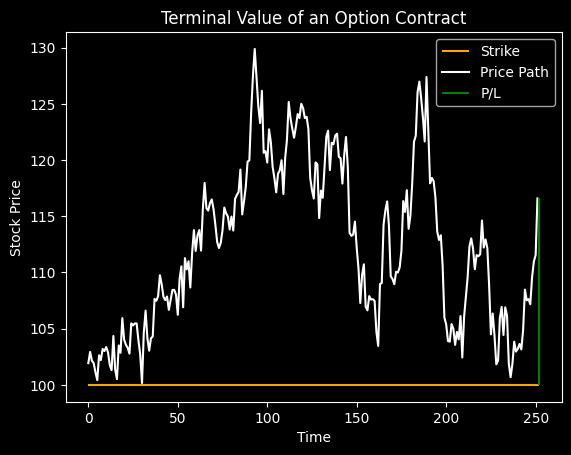

Premium at t=0: 14.231254785985819
P/L: 2.3554246652837136


In [13]:
import matplotlib.pyplot as plt
import qfin as qf

# Simulate the dynamics of the underlying asset according to Geometric Brownian Motion
path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)

# Creating a chart of the price path and the strike price
plt.title("Terminal Value of an Option Contract")
plt.hlines(100, 0, 252, label= 'Strike', color ='orange')
plt.plot(path.simulated_path, label = 'Price Path', color='white')
if max(path.simulated_path[-1] - 100, 0) == 0:
    plt.vlines(252, path.simulated_path[-1], 100, color ='red', label="P/L")
else:
    plt.vlines(252, 100, path.simulated_path[-1], color ='green', label="P/L")
plt.style.use('dark_background')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Print the premium and the resulting P/L
print("Premium at t=0:", black_scholes_call(100, 100, .3, .05, 1))
print("P/L:", max(path.simulated_path[-1] - 100, 0) - black_scholes_call(100, 100, .3, .05, 1))

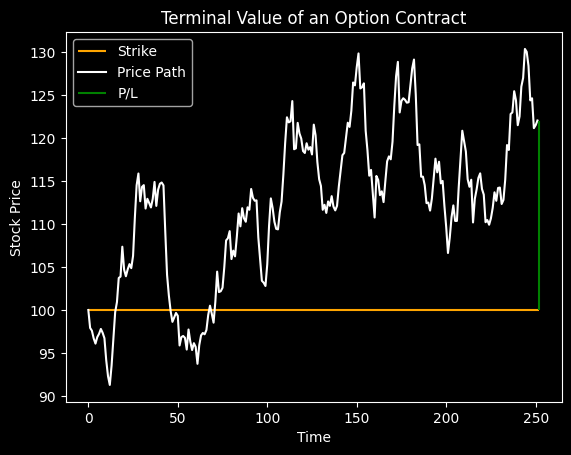

Premium at t=0: 14.231254785985819
P/L: 7.826232621039303


In [36]:
S0 = 100
K = 100
mu = 0.05
sigma = 0.3
dt = 1/252
steps = 252
T = 1

def simulate_gbm(S0, mu, sigma, dt, steps):
    S = np.zeros(steps)
    S[0] = S0

    for t in range(1, steps):
        Z = np.random.normal()
        S[t] = S[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return S

S = simulate_gbm(100, 0.05, .3, 1/252, 252)

# plt.plot(simulate_gbm(100, 0.05, .3, 1/252, 252))

plt.title("Terminal Value of an Option Contract")

plt.hlines(K,0,steps,label='Strike',color='orange')
plt.plot(S,label='Price Path',color='white')

if max(S[-1]-K,0)==0:
    plt.vlines(steps,S[-1],K,color='red',label="P/L")
else:
    plt.vlines(steps,K,S[-1],color='green',label="P/L")

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


premium = black_scholes_call(S0,K,sigma,mu,T)

print("Premium at t=0:",premium)
print("P/L:",max(S[-1]-K,0)-premium)

In [3]:
n_paths = 200000

payoffs = []

for i in range(n_paths):

    S = S0

    for t in range(steps):

        Z = np.random.normal()

        S = S*np.exp((mu-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

    payoff = max(S-K,0)

    payoffs.append(payoff)

price = np.exp(-mu*T)*np.mean(payoffs)

print("Monte Carlo Price:",price)

NameError: name 'S0' is not defined

In [57]:
print("Call Price:", black_scholes_call(100, 100, .3, .05, 1))
print("Market Maker Quote:", "13.43 @ 14.10")
print("Trade Edge:", black_scholes_call(100, 100, .3, .05, 1) - 14.10)

Call Price: 14.231254785985819
Market Maker Quote: 13.43 @ 14.10
Trade Edge: 0.13125478598581886


In [71]:
premium = 14.10 * 100
pls = []

for i in range(100000):
    path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)
    pls.append(max(path.simulated_path[-1] - 100, 0) * 100 - premium)
np.mean(pls)

100.081301295948

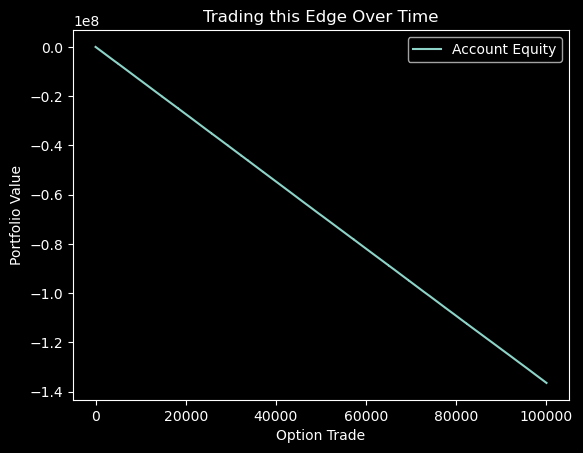

In [75]:
premium = 14.10 * 100
pls = []

for i in range(100000):
    path = qf.simulations.GeometricBrownianMotion(100, -0.5, .3, 1/252, 1)
    pls.append(max(path.simulated_path[-1] - 100, 0) * 100 - premium)
    
plt.title("Trading this Edge Over Time")
plt.plot(np.cumsum(pls), label="Account Equity")
plt.style.use('dark_background')
plt.xlabel('Option Trade')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

In [4]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

strikes = np.array([80, 90, 100, 110, 120])
maturities = np.array([0.25, 0.5, 1.0, 2.0]) # in years

# Rows = maturities, Columns = strikes
# Slight smile/skew structure + mild term structure
iv_surface = np.array([
    [0.20, 0.18, 0.16, 0.15, 0.14], # 3 months
    [0.22, 0.20, 0.18, 0.17, 0.16], # 6 months
    [0.24, 0.22, 0.20, 0.19, 0.18], # 1 year
    [0.26, 0.24, 0.22, 0.21, 0.20] # 2 years
])

iv_df = pd.DataFrame(iv_surface, index=maturities, columns=strikes)
print("Implied Volatility Surface:")
print(iv_df)

Implied Volatility Surface:
       80    90    100   110   120
0.25  0.20  0.18  0.16  0.15  0.14
0.50  0.22  0.20  0.18  0.17  0.16
1.00  0.24  0.22  0.20  0.19  0.18
2.00  0.26  0.24  0.22  0.21  0.20


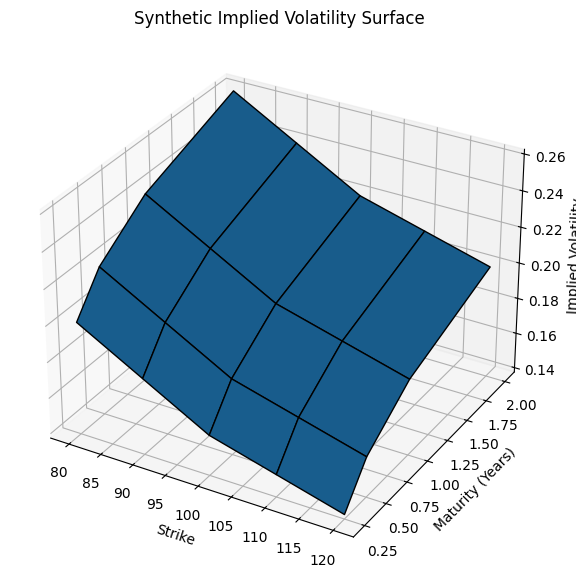

In [6]:
X, Y = np.meshgrid(strikes, maturities)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, iv_surface, edgecolor='black')
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (Years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("Synthetic Implied Volatility Surface")
plt.show()

In [7]:
vol_interpolator = RegularGridInterpolator(
    (maturities, strikes),
    iv_surface,
    bounds_error=False,
    fill_value=None
)

def get_interpolated_vol(K, T):
    vol = vol_interpolator([[T, K]])[0]
    return float(vol)

In [13]:
S = 100
K_test = 105
T_test = 0.75
r = 0.05

sigma_surface = get_interpolated_vol(K_test, T_test)
price_surface = black_scholes_call(S, K_test, sigma_surface, r, T_test)

print(f"Interpolated vol for K={K_test}, T={T_test}: {sigma_surface:.4f}")
print(f"Option price using vol surface: {price_surface:.4f}")

Interpolated vol for K=105, T=0.75: 0.1850
Option price using vol surface: 5.8693


In [14]:
flat_sigma = 0.25
price_flat = black_scholes_call(S, K_test, flat_sigma, r, T_test)

print(f"Flat-vol price: {price_flat:.4f}")
print(f"Surface-vol price: {price_surface:.4f}")
print(f"Difference: {price_surface - price_flat:.4f}")

Flat-vol price: 8.1135
Surface-vol price: 5.8693
Difference: -2.2442
